<a href="https://colab.research.google.com/github/SithphawitSangkaha/Deep-Learning-class/blob/main/projects/Copy_of_DL(3_2)_66110043_Sithphawit_Sangkaha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import scipy
from tensorflow.keras import backend as K
from matplotlib.ticker import MaxNLocator
from IPython.display import clear_output
from scipy import optimize
from matplotlib.gridspec import GridSpec
from IPython.display import Image
from tensorflow.keras import initializers
from IPython.display import Javascript
from datetime import datetime
import os
import random
import time

SEED = 42

# Set the environment variables for reproducibility.
os.environ['TF_DETERMINISTIC_OPS'] = '1' # Enable deterministic operations. (TensorFlow가 연산을 수행할 때 매번 동일한 순서와 방식을 사용하도록 결정론적(Deterministic) 연산을 활성화합니다.)
os.environ['TF_CUDNN_DETERMINISTIC'] = '1' # Force cuDNN to use deterministic algorithms. (GPU 연산 라이브러리인 cuDNN이 무작위성을 줄이고 결정론적 알고리즘만 사용하도록 강제합니다.)
os.environ['PYTHONHASHSEED'] = '0' # Fix Python hash seed for reproducibility. (파이썬의 문자열 및 객체 해시 생성 알고리즘에 고정된 시드(Seed)를 부여하여 무작위 요소를 제거합니다.)

# Set the environment variables for reproducibility.
tf.config.threading.set_inter_op_parallelism_threads(1) # 서로 독립적인 연산(Op)들을 동시에 병렬 처리할 때 사용할 쓰레드 수를 1개로 제한합니다.
tf.config.threading.set_intra_op_parallelism_threads(1) # 하나의 단일 연산(예: 대형 행렬 곱셈) 내부에서 멀티쓰레딩으로 나누어 처리할 쓰레드 수를 1개로 제한합니다.

# Set global random seeds
tf.random.set_seed(SEED) # 텐서플로 난수 생성기의 시드를 고정합니다.
np.random.seed(SEED) # 넘파이 난수 생성기의 시드를 고정합니다.
random.seed(SEED) # 파이썬 기본 random 모듈의 시드를 고정합니다.

initializer = tf.keras.initializers.GlorotNormal(seed=SEED) # 신경망 가중치 초기화 시 동일한 난수를 사용하도록 시드를 지정한 초기화 객체를 생성합니다.

In [34]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, MaxPooling2D, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [35]:
# # x in [-2*pi, 2*pi]
# x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)
# # Analytical solution
# def f(x):
#   return np.exp(-x**2) * np.sin(5*x) + np.tanh(x)*np.cos(10*x**2)
# y = f(x)
# 1. The Core Requirement: Self-Supervised PINN Loss Function
def pinn_loss(x_true, y_pred):
    # In self-supervised learning, we pass 'x' as both the input and the target.
    # Therefore, 'x_true' is actually our x input.
    # We dynamically calculate the analytical equation using TensorFlow operations:
    y_actual = tf.exp(-tf.square(x_true)) * tf.sin(5.0 * x_true) + \
               tf.tanh(x_true) * tf.cos(10.0 * tf.square(x_true))

    # Return the RMSE between the network's prediction and the equation's output
    return tf.sqrt(tf.reduce_mean(tf.square(y_pred - y_actual)))

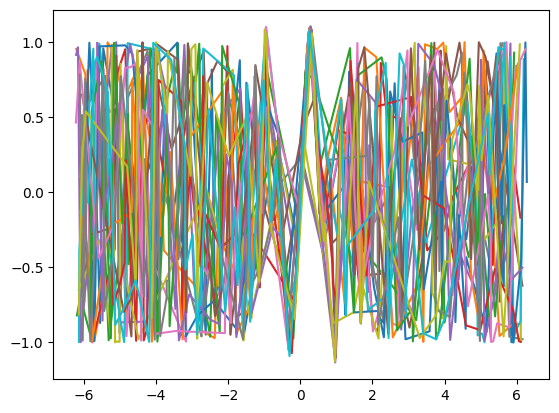

In [36]:
# Create input samples for the other tasks in different manner with different intervals in between
def generate_data(it, It, sn): # sampling for training
    x = np.random.uniform(it, It, sn) # Sampling randomly for training the meta_model.
    x = np.sort(x) # Sorting input samples
    y = np.exp(-x**2) * np.sin(5*x) + np.tanh(x)*np.cos(10*x**2) # given nonlinear equation
    #? y = x + 2
    return x, y

# Initialize arrays
s_x = [None] * task_No # for support training data
s_y = [None] * task_No
q_x = [None] * task_No # for query training data
q_y = [None] * task_No

# Generate data randomly for training each task
for i in range(task_No):
    s_x[i], s_y[i] = generate_data(it, It, sn_train) # for support tasks
    q_x[i], q_y[i] = generate_data(it, It, sn_train) # for query tasks
    # Print input data
    plt.plot(s_x[i], s_y[i])
    plt.plot(q_x[i], q_y[i])
meta_x, meta_y = generate_data(it, It, sn_train) # for a meta-learning

# Generate data regularly for testing the meta-model
meta_test_x = np.linspace(it, It, sn_test)
meta_test_y = np.exp(-meta_test_x**2) * np.sin(5*meta_test_x) + np.tanh(meta_test_x)*np.cos(10*meta_test_x**2) # A given nonlinear equation

In [37]:
# Split into 800 training samples and 200 test samples

# Generate the full 1000 points
x_all = np.linspace(-2 * np.pi, 2 * np.pi, 1000).reshape(-1, 1)

# Split into 800 training and 200 testing samples
# Note: We are only splitting 'x' because we don't use 'y' labels for training
x_train, x_test = train_test_split(x_all, test_size=200, random_state=SEED)

In [38]:
# 3. Model Architecture (Fourier Features + MLP)
class FourierFeatureMapping(tf.keras.layers.Layer):
    def __init__(self, num_features=256, scale=12.0, **kwargs):
        super().__init__(**kwargs)
        self.num_features = num_features
        self.scale = scale

    def build(self, input_shape):
        self.b = self.add_weight(
            shape=(input_shape[-1], self.num_features),
            initializer=tf.keras.initializers.RandomNormal(stddev=self.scale, seed=SEED),
            trainable=False,
            name='fourier_b'
        )
        super().build(input_shape)

    def call(self, inputs):
        proj = 2.0 * np.pi * tf.matmul(inputs, self.b)
        return tf.concat([tf.sin(proj), tf.cos(proj)], axis=-1)
#MLP
def create_model():
    model_instance = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(1,)),
        FourierFeatureMapping(num_features=128, scale=3.0),
        tf.keras.layers.Dense(256, activation='swish', kernel_initializer=initializer),
        tf.keras.layers.Dense(256, activation='swish', kernel_initializer=initializer),
        tf.keras.layers.Dense(256, activation='swish', kernel_initializer=initializer),
        tf.keras.layers.Dense(1, kernel_initializer=initializer)
    ])
    return model_instance

In [39]:
# Create models for support and query tasks
s_models = [create_model() for _ in range(task_No)]
q_models = [create_model() for _ in range(task_No)]

In [40]:
# Hyperparameters

learning_rate = 0.001
batch_size = 800
num_epochs = 3000

In [44]:
# Meta-Learning (MAML) PiNN Training Loop
# Define meta-optimizers and meta-model
meta_model = create_model()
meta_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
inner_lr = 0.01  # Step size for inner loop adaptation
meta_epochs = 100

def meta_train_step(meta_model, support_x, query_x):
    # Keep track of gradients for the outer loop update
    with tf.GradientTape() as outer_tape:
        # Store original weights
        original_weights = [tf.identity(w) for w in meta_model.trainable_variables]
        total_query_loss = 0.0

        for i in range(task_No):
            # 1. Inner loop gradient computation on support set
            with tf.GradientTape() as inner_tape:
                s_loss = pinn_loss(support_x[i], meta_model(support_x[i]))

            inner_grads = inner_tape.gradient(s_loss, meta_model.trainable_variables)

            # 2. Fast adaptation: temporarily assign adapted weights
            for var, grad in zip(meta_model.trainable_variables, inner_grads):
                if grad is not None:
                    var.assign_sub(inner_lr * grad)

            # 3. Compute loss on Query Set under adapted weights
            q_loss = pinn_loss(query_x[i], meta_model(query_x[i]))
            total_query_loss += q_loss

            # 4. Restore original weights before processing next task
            for var, orig in zip(meta_model.trainable_variables, original_weights):
                var.assign(orig)

        # Average query loss across all tasks
        meta_loss = total_query_loss / task_No

    # 5. Outer Loop: Update meta-model parameters using query gradients
    meta_grads = outer_tape.gradient(meta_loss, meta_model.trainable_variables)
    meta_optimizer.apply_gradients(zip(meta_grads, meta_model.trainable_variables))
    return meta_loss

# Run the Meta-Training Loop
print("Starting Meta-Learning PiNN Training...")
meta_history = []
for epoch in range(1, meta_epochs + 1):
    loss_val = meta_train_step(meta_model, tf.convert_to_tensor(s_x, dtype=tf.float32), tf.convert_to_tensor(q_x, dtype=tf.float32))
    meta_history.append(loss_val.numpy())
    if epoch % 10 == 0 or epoch == 1:
        print(f"Meta-Epoch {epoch}/{meta_epochs} - Meta-Query-Loss: {loss_val.numpy():.6f}")

print("Meta-learning process complete!")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Starting Meta-Learning PiNN Training...
Meta-Epoch 1/100 - Meta-Query-Loss: 0.693853
Meta-Epoch 10/100 - Meta-Query-Loss: 0.670843
Meta-Epoch 20/100 - Meta-Query-Loss: 0.669931
Meta-Epoch 30/100 - Meta-Query-Loss: 0.669340
Meta-Epoch 40/100 - Meta-Query-Loss: 0.669057
Meta-Epoch 50/100 - Meta-Query-Loss: 0.668943
Meta-Epoch 60/100 - Meta-Query-Loss: 0.668854
Meta-Epoch 70/100 - Meta-Query-Loss: 0.668782
Meta-Epoch 80/100 - Meta-Query-Loss: 0.668721
Meta-Epoch 90/100 - Meta-Query-Loss: 0.668667
Meta-Epoch 100/100 - Meta-Query-Loss: 0.668617
Meta-learning process complete!


In [45]:
# 5. Output and Plotting Requirements
# Calculate explicit Test RMSE on the meta test dataset using our meta_model
# Reshape meta_test_x to ensure it is in batch format (N, 1)
x_test_tensor = tf.convert_to_tensor(meta_test_x.reshape(-1, 1), dtype=tf.float32)

y_pred_test = meta_model.predict(x_test_tensor, verbose=0).flatten()
y_actual_test = meta_test_y

test_rmse = np.sqrt(np.mean((y_pred_test - y_actual_test)**2))
print(f"AUTOMATIC TEST RMSE (Meta-Model 200 Samples): {test_rmse:.6f}")

AUTOMATIC TEST RMSE (Meta-Model 200 Samples): 0.690051


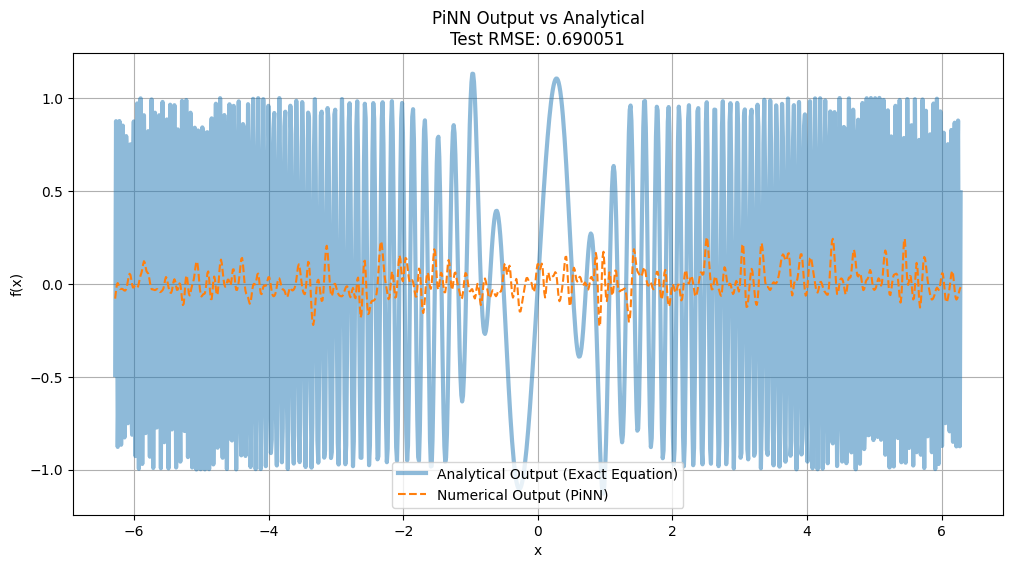

In [46]:
# For plotting, we predict on the ENTIRE sorted dataset (x_all)
# so the plotted lines are smooth and continuous, matching the assignment image.
y_pred_all = meta_model.predict(x_all, verbose=0)
y_actual_all = np.exp(-x_all**2) * np.sin(5*x_all) + np.tanh(x_all)*np.cos(10*x_all**2)

plt.figure(figsize=(12, 6))
plt.plot(x_all, y_actual_all, label="Analytical Output (Exact Equation)", color="tab:blue", linewidth=3, alpha=0.5)
plt.plot(x_all, y_pred_all, label="Numerical Output (PiNN)", color="tab:orange", linestyle="--", linewidth=1.5)

plt.title(f"PiNN Output vs Analytical\nTest RMSE: {test_rmse:.6f}")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

In [47]:
# Plot training loss

plt.plot(meta_history.meta_history['loss'], label='Train RMSE')
plt.plot(meta_history.meta_history['val_loss'], label='Validation RMSE')

plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('RMSE Loss')
plt.title('MLP Training History')

plt.legend()
plt.grid(True)
plt.show()

AttributeError: 'list' object has no attribute 'meta_history'